# Solar Activity Prediction using SILSO Data

In [ ]:

# Install necessary libraries
!pip install pandas numpy matplotlib tensorflow sklearn fbprophet prophet


## Load and Preprocess the Data

In [ ]:
import pandas as pd

# Load SILSO data
url = 'https://www.sidc.be/SILSO/DATA/SN_d_tot_V2.0.txt'
columns = ['year', 'month', 'day', 'decimal_date', 'daily_total_sunspot', 'standard_deviation', 'observed_number']

# Load data, skipping problematic rows
data = pd.read_csv(
    url,
    delim_whitespace=True,
    names=columns,
    comment='#',
    on_bad_lines='skip'  # Skip problematic rows
)

# Convert to datetime
data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
data.set_index('date', inplace=True)

# Display the first few rows
data.head()


<ipython-input-1-a332046ad252>:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(


,year,month,day,decimal_date,daily_total_sunspot,standard_deviation,observed_number
date,,,,,,,
1818-01-01,1818,1,1,1818.001,-1,-1.0,0
1818-01-02,1818,1,2,1818.004,-1,-1.0,0
1818-01-03,1818,1,3,1818.007,-1,-1.0,0
1818-01-04,1818,1,4,1818.010,-1,-1.0,0
1818-01-05,1818,1,5,1818.012,-1,-1.0,0


## Visualize Solar Cycles

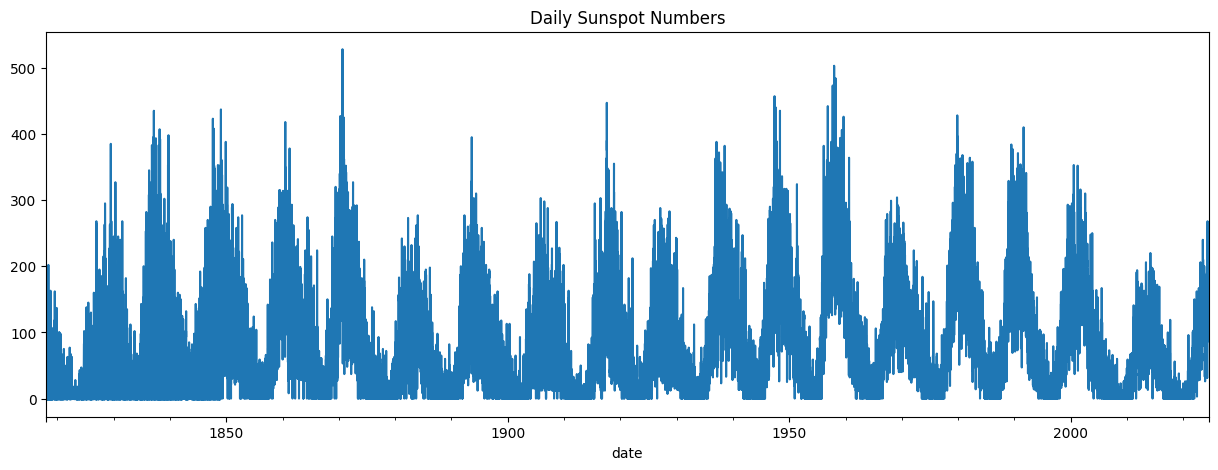

In [ ]:

import matplotlib.pyplot as plt

data['daily_total_sunspot'].plot(figsize=(15, 5), title="Daily Sunspot Numbers")
plt.show()


## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = data.index.to_julian_date().values.reshape(-1, 1)  # Feature: Julian date
y = data['daily_total_sunspot']  # Target: Sunspot count

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Random Forest Model for Prediction

In [ ]:

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, y_pred))


MAE: 15.173124295657939


## Forecasting with LSTM

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Prepare data for LSTM
sequence_length = 30
X_lstm = []
y_lstm = []
for i in range(len(y) - sequence_length):
    X_lstm.append(y[i:i + sequence_length])
    y_lstm.append(y[i + sequence_length])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split into train and test sets
split = int(0.8 * len(X_lstm))
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

# Reshape for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# LSTM Model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Predictions
y_pred = model.predict(X_test)


<ipython-input-13-0729250833bd>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_lstm.append(y[i + sequence_length])


Epoch 1/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 5222.3086
Epoch 2/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 2246.8086
Epoch 3/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 2573.6099
Epoch 4/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - loss: 3057.1069
Epoch 5/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - loss: 2023.6595
Epoch 6/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 1850.0134
Epoch 7/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 2335.2307
Epoch 8/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 1699.6802
Epoch 9/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 1323.6152
Epoch 10/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 1293.5262
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import pandas as pd

# Load the dataset from the URL
url = 'https://www.sidc.be/SILSO/DATA/SN_d_tot_V2.0.txt'
columns = ['year', 'month', 'day', 'decimal_date', 'daily_total_sunspot', 'standard_deviation', 'observed_number']

# Load data and clean it
data = pd.read_csv(
    url,
    delim_whitespace=True,
    names=columns,
    comment='#',
    on_bad_lines='skip'
)

# Preprocess the data: Combine year, month, and day into a datetime column
data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
data.set_index('date', inplace=True)

# Extract sunspot data
y = data['daily_total_sunspot'].values

# Define sequence length (5 years = 1825 days)
sequence_length = 365 * 5  # 5 years of data

# Prepare data for LSTM
X_lstm = []
y_lstm = []
for i in range(len(y) - sequence_length):
    X_lstm.append(y[i:i + sequence_length])
    y_lstm.append(y[i + sequence_length])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split into train and test sets (80% training, 20% testing)
split = int(0.8 * len(X_lstm))
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

# Reshape for LSTM input (3D format: samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Predictions on the test set
y_pred = model.predict(X_test)

# Optionally, evaluate the model (e.g., using MAE or RMSE)
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Predict future sunspot counts (next 6 months or next time step after training)
# Generate Julian dates for prediction (you can choose the dates you're predicting for)
future_dates = pd.date_range(start="2024-07-01", periods=1825, freq='D')  # Example: Next 5 years of predictions
future_julian_dates = future_dates.to_julian_date().values.reshape(-1, 1)

# Predict sunspot counts for these future dates
y_future_pred = model.predict(future_julian_dates)

# Create DataFrame for the predicted future sunspot counts
future_sunspots = pd.DataFrame({
    'date': future_dates,
    'predicted_sunspot': y_future_pred.flatten()
})

# Display the predicted future sunspots
print(future_sunspots)

# Optional: Plot the predicted values for future sunspot activity
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.plot(future_sunspots['date'], future_sunspots['predicted_sunspot'], label="Predicted Sunspot Numbers")
plt.title("Predicted Sunspot Numbers (Next 5 Years)")
plt.xlabel("Date")
plt.ylabel("Predicted Sunspot Count")
plt.grid(True)
plt.show()


<ipython-input-14-d8d833836846>:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1218/1840 ━━━━━━━━━━━━━━━━━━━━ 6:02 583ms/step - loss: nan

KeyboardInterrupt: 

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset from the URL
url = 'https://www.sidc.be/SILSO/DATA/SN_d_tot_V2.0.txt'
columns = ['year', 'month', 'day', 'decimal_date', 'daily_total_sunspot', 'standard_deviation', 'observed_number']

# Load data and clean it
data = pd.read_csv(
    url,
    delim_whitespace=True,
    names=columns,
    comment='#',
    on_bad_lines='skip'
)

# Preprocess the data: Combine year, month, and day into a datetime column
data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
data.set_index('date', inplace=True)

# Extract sunspot data
y = data['daily_total_sunspot'].values

# Define sequence length (5 years = 1825 days)
sequence_length = 365 * 5  # 5 years of data

# Prepare data for LSTM
X_lstm = []
y_lstm = []
for i in range(len(y) - sequence_length):
    X_lstm.append(y[i:i + sequence_length])
    y_lstm.append(y[i + sequence_length])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split into train and test sets (80% training, 20% testing)
split = int(0.8 * len(X_lstm))
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

# Reshape for LSTM input (3D format: samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Predictions on the test set
y_pred = model.predict(X_test)

# Optionally, evaluate the model (e.g., using MAE or RMSE)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Now, we will predict sunspot counts from July 2024 to December 2024.
# First, we need to extract the last 5 years of data from the training set (up to June 2024)

last_5_years_data = y[-sequence_length:]  # The last 5 years of data (the latest sequence)
X_future = last_5_years_data.reshape((1, sequence_length, 1))  # Reshape for LSTM input

# Predict future sunspot counts for the next 6 months (183 days)
future_dates = pd.date_range(start="2024-07-01", periods=183, freq='D')  # Next 6 months (183 days)

# Predict sunspot counts for the future dates
y_future_pred = []
for _ in range(len(future_dates)):
    # Predict the next sunspot value
    next_pred = model.predict(X_future)
    y_future_pred.append(next_pred[0][0])

    # Update the input sequence with the predicted value (to predict the next day)
    X_future = np.roll(X_future, -1, axis=1)
    X_future[0, -1, 0] = next_pred  # Set the predicted value as the new last value

# Create DataFrame for the predicted future sunspot counts
future_sunspots = pd.DataFrame({
    'date': future_dates,
    'predicted_sunspot': y_future_pred
})

# Display the predicted future sunspots
print(future_sunspots)

# Optional: Plot the predicted values for future sunspot activity
plt.figure(figsize=(15, 5))
plt.plot(future_sunspots['date'], future_sunspots['predicted_sunspot'], label="Predicted Sunspot Numbers")
plt.title("Predicted Sunspot Numbers (July 2024 - December 2024)")
plt.xlabel("Date")
plt.ylabel("Predicted Sunspot Count")
plt.grid(True)
plt.show()


<ipython-input-5-34446fa0042f>:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(url, delim_whitespace=True, names=columns, comment='#', on_bad_lines='skip')
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 0.0056
Epoch 2/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 0.0040
Epoch 3/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.0041
Epoch 4/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0039
Epoch 5/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 0.0040
Epoch 6/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 0.0039
Epoch 7/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.0039
Epoch 8/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.0039
Epoch 9/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - loss: 0.0039
Epoch 10/10
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.0036
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━

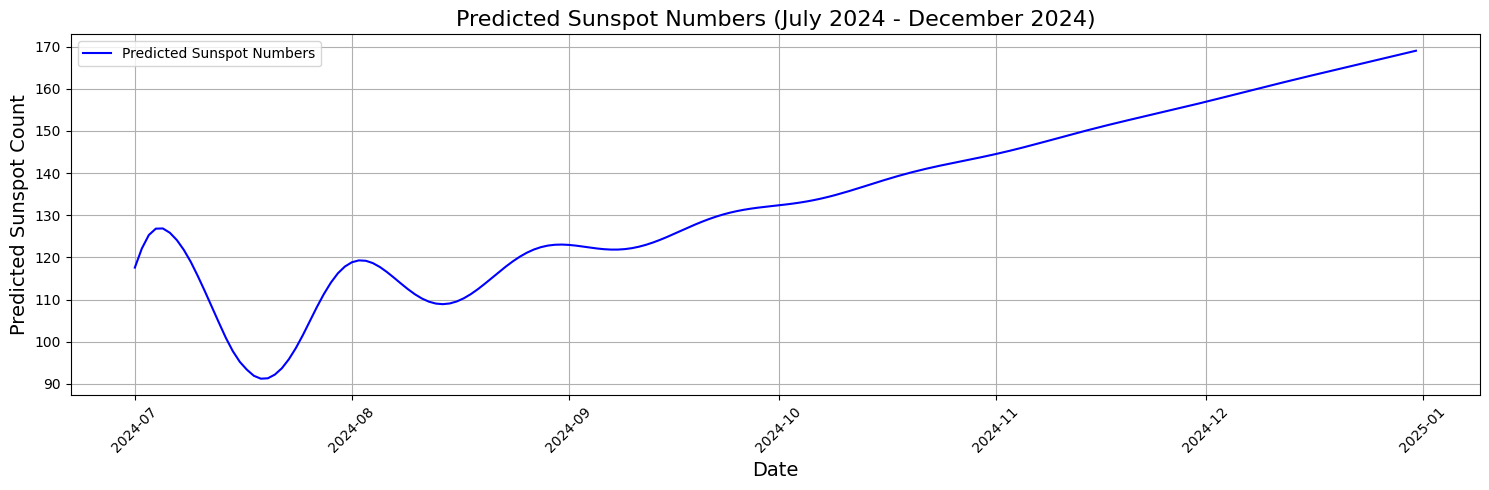

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Load and preprocess the data (assuming this part is already done)
# Example preprocessing step (you should have already done this):
url = 'https://www.sidc.be/SILSO/DATA/SN_d_tot_V2.0.txt'
columns = ['year', 'month', 'day', 'decimal_date', 'daily_total_sunspot', 'standard_deviation', 'observed_number']
data = pd.read_csv(url, delim_whitespace=True, names=columns, comment='#', on_bad_lines='skip')

# Convert to datetime and set index
data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
data.set_index('date', inplace=True)

# Normalize the data (standardize or scale as necessary)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data['daily_total_sunspot'].values.reshape(-1, 1))

# Prepare the data for LSTM (create sequences)
sequence_length = 30
X_lstm = []
y_lstm = []
for i in range(len(scaled_data) - sequence_length):
    X_lstm.append(scaled_data[i:i + sequence_length])
    y_lstm.append(scaled_data[i + sequence_length])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Split into train and test sets (80% training, 20% testing)
split = int(0.8 * len(X_lstm))
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

# Reshape for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Generate future dates (July 2024 - December 2024)
future_dates = pd.date_range(start="2024-07-01", end="2024-12-31", freq="D")

# Start with the most recent sequence from the training data (last 30 days)
X_last = X_train[-1]  # Last available sequence from the training data
y_future_pred = []  # List to hold predictions for future dates

# Predict day by day, updating the input sequence with each prediction
for i in range(len(future_dates)):
    # Reshape X_last to match the LSTM model input format
    X_input = X_last.reshape(1, X_last.shape[0], 1)

    # Predict the sunspot count for the next day
    next_pred = model.predict(X_input)[0]

    # Append the predicted value
    y_future_pred.append(next_pred)

    # Update X_last with the new prediction for the next step
    X_last = np.roll(X_last, -1)  # Roll the sequence by one
    X_last[-1] = next_pred  # Update the last value with the new prediction

# Convert the predicted values to 1D array for inverse transformation
y_future_pred = np.array(y_future_pred).reshape(-1, 1)

# Inverse transformation to get back to original scale
predicted_sunspots = scaler.inverse_transform(y_future_pred)

# Create DataFrame for predicted sunspot counts
future_sunspots = pd.DataFrame({
    'date': future_dates,  # Date range from July 2024 to December 2024
    'predicted_sunspot': predicted_sunspots.flatten()  # Flatten to make it 1D for the DataFrame
})

# Display the predicted future sunspots
print(future_sunspots)

# Plotting the predicted sunspot numbers from July 2024 to December 2024
plt.figure(figsize=(15, 5))  # Set the size of the plot
plt.plot(future_sunspots['date'], future_sunspots['predicted_sunspot'], label="Predicted Sunspot Numbers", color='b')
plt.title("Predicted Sunspot Numbers (July 2024 - December 2024)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Predicted Sunspot Count", fontsize=14)
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.tight_layout()  # Adjust layout to ensure no labels are cut off
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from prophet import Prophet
import matplotlib.pyplot as plt

# Load the dataset
url = 'https://www.sidc.be/SILSO/DATA/SN_d_tot_V2.0.txt'
columns = ['year', 'month', 'day', 'daily_total_sunspot', 'daily_standard_deviation', 'n_obs', 'definitive_marker']
data = pd.read_csv(url, delim_whitespace=True, names=columns, comment='#', on_bad_lines='skip')

# Convert to datetime
data['date'] = pd.to_datetime(data[['year', 'month', 'day']])
data = data[['date', 'daily_total_sunspot']]

# Prepare the data
sequence_length = 30
sunspot_values = data['daily_total_sunspot'].values
scaler = StandardScaler()
scaled_values = scaler.fit_transform(sunspot_values.reshape(-1, 1))

X = []
y = []

for i in range(sequence_length, len(scaled_values)):
    X.append(scaled_values[i-sequence_length:i])
    y.append(scaled_values[i])

X = np.array(X)
y = np.array(y)

# Train-test split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)

# Predict future sunspots
X_last = X[-1].reshape(1, sequence_length, 1)
y_future_pred = []

for _ in range(180):  # Predict for 180 days (July 2024 - December 2024)
    next_pred = model.predict(X_last)[0][0]
    y_future_pred.append(next_pred)
    X_last = np.append(X_last[:, 1:, :], [[next_pred]], axis=1)

# Inverse transform predictions
y_future_pred = scaler.inverse_transform(np.array(y_future_pred).reshape(-1, 1))

# Prepare future dates
future_dates = pd.date_range(start='2024-07-01', end='2024-12-31')
predicted_sunspots = pd.DataFrame({'date': future_dates, 'predicted_sunspots': y_future_pred.flatten()})

# Plot predictions
plt.figure(figsize=(15, 5))
plt.plot(predicted_sunspots['date'], predicted_sunspots['predicted_sunspots'], label="Predicted Sunspots", color='blue')
plt.title("Predicted Sunspot Numbers (July 2024 - December 2024)")
plt.xlabel("Date")
plt.ylabel("Sunspot Count")
plt.grid()
plt.legend()
plt.show()


<ipython-input-22-3da14af39b52>:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(url, delim_whitespace=True, names=columns, comment='#', on_bad_lines='skip')


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1885/1885 ━━━━━━━━━━━━━━━━━━━━ 74s 38ms/step - loss: 0.0068 - val_loss: 2.8158e-04 - learning_rate: 0.0010
Epoch 2/50
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - loss: 6.5159e-04 - val_loss: 8.2194e-04 - learning_rate: 0.0010
Epoch 3/50
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - loss: 4.1635e-04 - val_loss: 6.5969e-04 - learning_rate: 0.0010
Epoch 4/50
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - loss: 3.6158e-04 - val_loss: 4.2765e-05 - learning_rate: 0.0010
Epoch 5/50
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - loss: 3.6030e-04 - val_loss: 3.2795e-04 - learning_rate: 0.0010
Epoch 6/50
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - loss: 3.5451e-04 - val_loss: 5.8851e-04 - learning_rate: 0.0010
Epoch 7/50
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - loss: 3.4739e-04 - val_loss: 3.4606e-04 - learning_rate: 0.0010
Epoch 8/50
1885/1885 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - loss: 3.4984e-04 - val_loss: 7.8655e-04 - learning_rate: 0.0010
Epoch 9/50
1885/1885 ━━━━━━━━━━━━━━━━━━

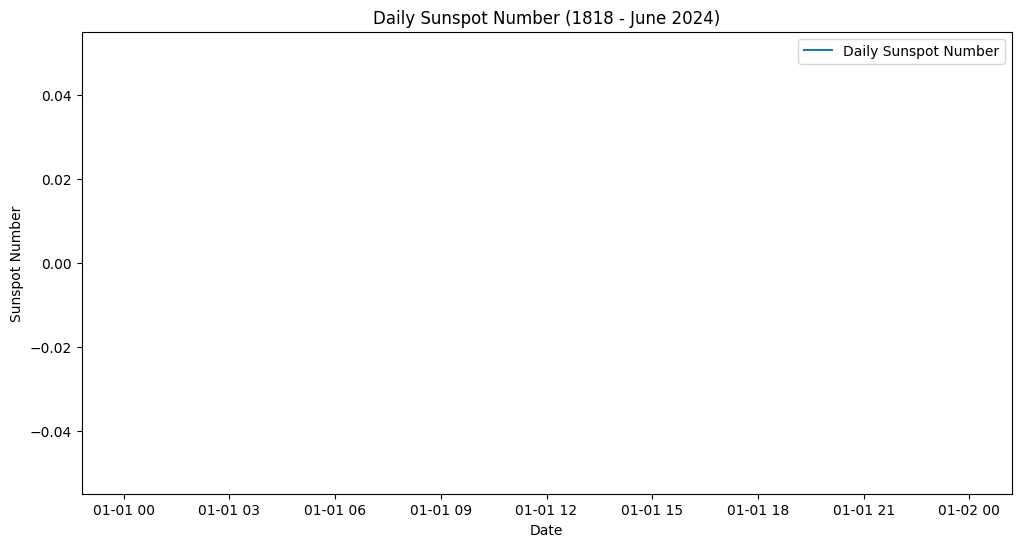

Test data is empty after preprocessing. Exiting...


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:534: RuntimeWarning: invalid value encountered in scalar divide
  return -self.loglike(params, *args) / nobs


ARIMA model failed: Schur decomposition solver error.
Prophet model failed: Insufficient data for Prophet model


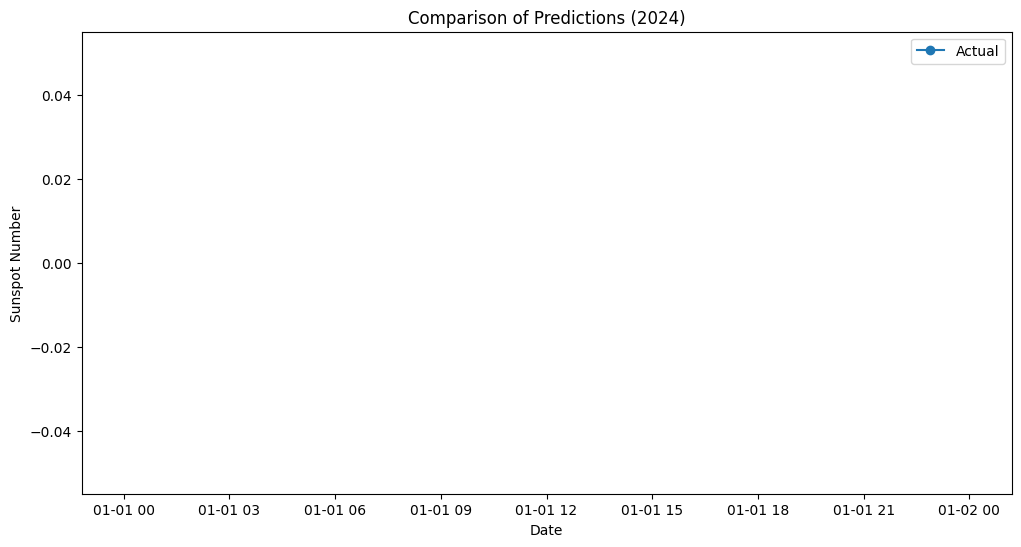

In [ ]:
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import matplotlib.pyplot as plt

# Define the URL for daily sunspot data
url = "https://www.sidc.be/SILSO/DATA/SN_d_tot_V2.0.txt"

# Step 1: Fetch and preprocess data
response = requests.get(url)
data = response.text

# Parse the data
rows = data.splitlines()
daily_data = []
columns = ["Year", "Month", "Day", "Fractional_Year", "Sunspot_Number", "Standard_Deviation", "Observations", "Definitive"]
for row in rows:
    if row.strip():
        row_data = row.split()
        # Ensure the row has the correct number of columns
        if len(row_data) == len(columns):
            daily_data.append(row_data)

# Create DataFrame
df = pd.DataFrame(daily_data, columns=columns)

# Convert columns to numeric types, handling errors
for col in ["Year", "Month", "Day", "Fractional_Year", "Sunspot_Number", "Standard_Deviation", "Observations", "Definitive"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with any NaN values
df.dropna(inplace=True)

# Filter data from 1818 to June 2024
filtered_df = df[(df['Year'] >= 1818) & ((df['Year'] < 2024) | ((df['Year'] == 2024) & (df['Month'] <= 6)))]

# Convert to datetime format
filtered_df['Date'] = pd.to_datetime(filtered_df[['Year', 'Month', 'Day']])
filtered_df.set_index('Date', inplace=True)

# Step 2: Visualize data
plt.figure(figsize=(12, 6))
plt.plot(filtered_df['Sunspot_Number'], label='Daily Sunspot Number')
plt.title('Daily Sunspot Number (1818 - June 2024)')
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend()
plt.show()

# Step 3: Train/Test Split
data_for_modeling = filtered_df['Sunspot_Number'].resample('MS').mean().dropna()

# Fill missing data in training/test sets
train_data = data_for_modeling[:'2023-12'].interpolate()
test_data = data_for_modeling['2024-01':'2024-06'].interpolate()

# Ensure test_data is not empty
if test_data.empty:
    print("Test data is empty after preprocessing. Exiting...")
    exit()

# Step 4: Train ARIMA Model
try:
    arima_model = ARIMA(train_data, order=(5, 1, 0))
    arima_result = arima_model.fit()
    # Forecast with ARIMA
    arima_forecast = arima_result.forecast(steps=len(test_data))
except Exception as e:
    print("ARIMA model failed:", e)
    arima_forecast = pd.Series([np.nan] * len(test_data), index=test_data.index)

# Step 5: Train Prophet Model
try:
    prophet_df = train_data.reset_index()
    prophet_df.columns = ['ds', 'y']
    if len(prophet_df) >= 2:
        prophet_model = Prophet()
        prophet_model.fit(prophet_df)

        future = prophet_model.make_future_dataframe(periods=6, freq='MS')
        forecast = prophet_model.predict(future)
        prophet_forecast = forecast[['ds', 'yhat']].set_index('ds').loc['2024-01':'2024-06']
    else:
        raise ValueError("Insufficient data for Prophet model")
except Exception as e:
    print("Prophet model failed:", e)
    prophet_forecast = pd.DataFrame(index=test_data.index, data={'yhat': [np.nan] * len(test_data)})

# Step 6: Compare Predictions
actual = test_data.values
arima_pred = arima_forecast.values if not arima_forecast.isnull().all() else np.array([np.nan] * len(test_data))
prophet_pred = prophet_forecast['yhat'].values if not prophet_forecast.empty else np.array([np.nan] * len(test_data))

# Metrics
def evaluate_model(actual, predicted, model_name):
    try:
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        print(f"{model_name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    except ValueError as e:
        print(f"{model_name} evaluation failed: {e}")

if not np.isnan(arima_pred).all():
    evaluate_model(actual, arima_pred, "ARIMA")
if not np.isnan(prophet_pred).all():
    evaluate_model(actual, prophet_pred, "Prophet")

# Step 7: Visualization
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, actual, label='Actual', marker='o')
if not np.isnan(arima_pred).all():
    plt.plot(test_data.index, arima_pred, label='ARIMA Predictions', marker='x')
if not np.isnan(prophet_pred).all():
    plt.plot(test_data.index, prophet_pred, label='Prophet Predictions', marker='s')
plt.title('Comparison of Predictions (2024)')
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend()
plt.show()

# Save Results
filtered_df.to_csv('filtered_sunspot_data.csv')
